### **导入基础库**

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.cm as cm

sns.set_theme(style="white") 
DPI = 600

os.makedirs("./gallery", exist_ok=True)


### **1. Regression Scatter (regplot)**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_01_regplot.png`

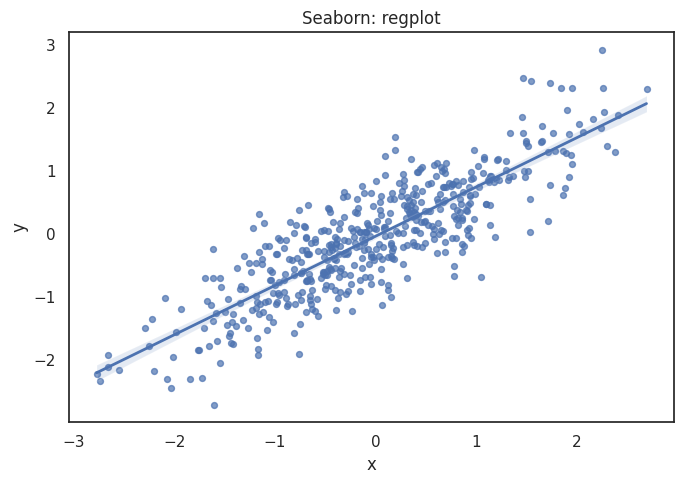

In [2]:
np.random.seed(0)
x = np.random.randn(500)
y = 0.8 * x + np.random.randn(500) * 0.5
df = pd.DataFrame({"x": x, "y": y})

plt.figure(figsize=(7, 5))
ax = sns.regplot(data=df, x="x", y="y", scatter_kws={"s": 18, "alpha": 0.7}, line_kws={"lw": 2})
ax.grid(False)

plt.title("Seaborn: regplot")
plt.tight_layout()
plt.savefig("./gallery/sns_01_regplot.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()


### **2. Joint KDE (jointplot)**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_02_joint_kde.png`

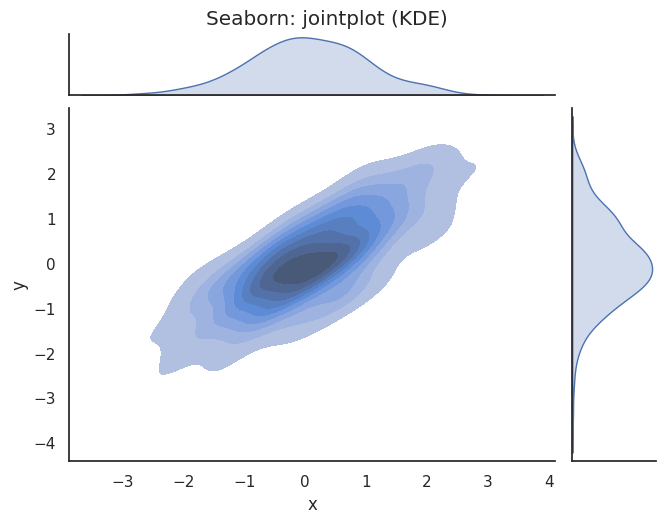

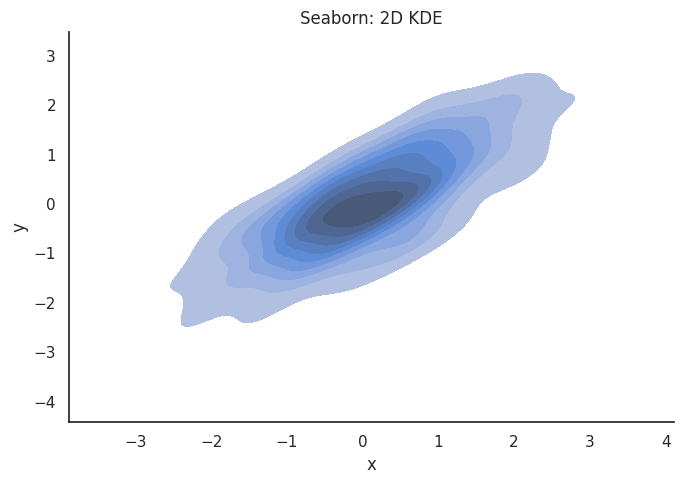

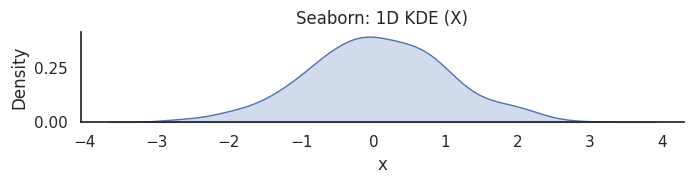

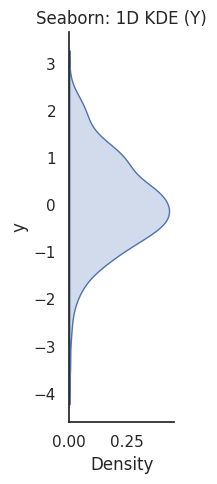

In [3]:
np.random.seed(1)
x = np.random.randn(400)
y = x * 0.7 + np.random.randn(400) * 0.6
df = pd.DataFrame({"x": x, "y": y})

# =========================================================
# (A) Joint KDE (jointplot): 2D KDE + 2 marginal 1D KDEs
# =========================================================
g = sns.jointplot(
    data=df,
    x="x",
    y="y",
    kind="kde",
    fill=True
)

# 显式指定最终输出尺寸（英寸）
g.figure.set_size_inches(7, 5)

# 关闭所有子图网格
g.ax_joint.grid(False)
g.ax_marg_x.grid(False)
g.ax_marg_y.grid(False)

# 去除上/右边框，让展示更“干净”
sns.despine(fig=g.figure)

g.figure.suptitle("Seaborn: jointplot (KDE)", y=1.02)
g.figure.savefig("./gallery/sns_02_joint_kde.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(g.figure)

# ==================================
# (B) 2D KDE only (single figure)
# ==================================
plt.figure(figsize=(7, 5))
ax = sns.kdeplot(
    data=df,
    x="x",
    y="y",
    fill=True
)
ax.grid(False)
sns.despine(ax=ax)

plt.title("Seaborn: 2D KDE")
plt.tight_layout()
plt.savefig("./gallery/sns_02b_kde2d.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

# ================================
# (C) 1D KDE only (X) single plot
# ================================
plt.figure(figsize=(7, 2))
ax = sns.kdeplot(
    data=df,
    x="x",
    fill=True
)
ax.grid(False)
sns.despine(ax=ax)

plt.title("Seaborn: 1D KDE (X)")
plt.tight_layout()
plt.savefig("./gallery/sns_02c_kde1d_x.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

# ================================
# (D) 1D KDE only (Y) single plot
# ================================
plt.figure(figsize=(2, 5))
ax = sns.kdeplot(
    data=df,
    y="y",
    fill=True
)
ax.grid(False)
sns.despine(ax=ax)

plt.title("Seaborn: 1D KDE (Y)")
plt.tight_layout()
plt.savefig("./gallery/sns_02d_kde1d_y.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()


### **3. Histogram + KDE (by category)**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_03_hist_kde.png`

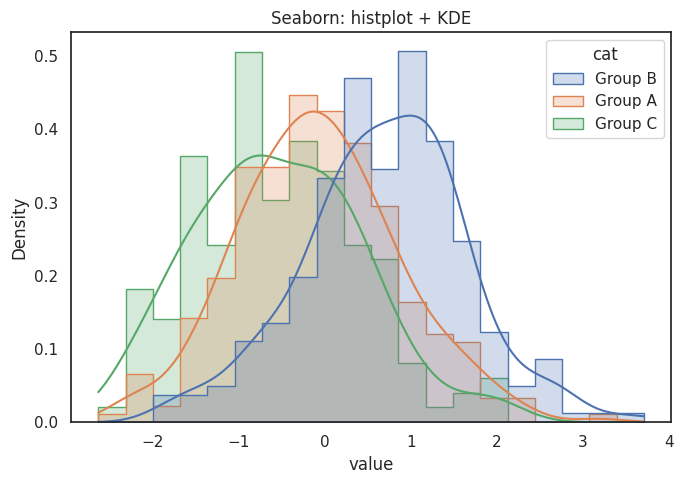

In [4]:
np.random.seed(2)
n = 700
cat = np.random.choice(["Group A", "Group B", "Group C"], size=n, p=[0.4, 0.35, 0.25])
value = np.random.randn(n) + (cat == "Group B") * 0.7 + (cat == "Group C") * (-0.5)
df = pd.DataFrame({"cat": cat, "value": value})

plt.figure(figsize=(7, 5))
ax = sns.histplot(data=df, x="value", hue="cat", kde=True, element="step", stat="density", common_norm=False)
ax.grid(False)

plt.title("Seaborn: histplot + KDE")
plt.tight_layout()
plt.savefig("./gallery/sns_03_hist_kde.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **4. Boxplot**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_04_boxplot.png`

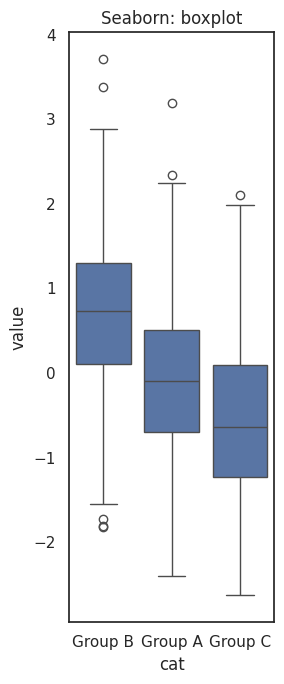

In [5]:
plt.figure(figsize=(3, 7))
ax = sns.boxplot(data=df, x="cat", y="value")
ax.grid(False)

plt.title("Seaborn: boxplot")
plt.tight_layout()
plt.savefig("./gallery/sns_04_boxplot.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **5. Violinplot**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_05_violinplot.png`

/tmp/ipykernel_1716180/1836924474.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_1716180/1836924474.py:26: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


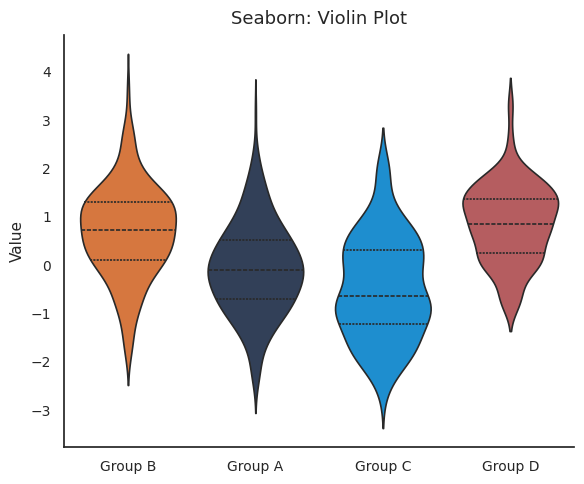

In [6]:
plt.figure(figsize=(6,5))

np.random.seed(2)
n = 700
cat = np.random.choice(
    ["Group A", "Group B", "Group C", "Group D"],
    size=n,
    p=[0.4, 0.35, 0.15, 0.1]
)
value = (
    np.random.randn(n)
    + (cat == "Group B") * 0.7
    + (cat == "Group C") * (-0.5)
    + (cat == "Group D") * 1.0
)

df_v = pd.DataFrame({"cat": cat, "value": value})

palette = {
    "Group A": "#2C3F5E",  # 蓝
    "Group B": "#EF7026",  # 橙
    "Group C": "#0096ED",  # 绿
    "Group D": "#C44E52",  # 红
}

ax = sns.violinplot(
    data=df_v,
    x="cat",
    y="value",
    inner="quartile",
    bw_method=0.35,
    linewidth=1.2,
    width=0.75,
    scale="width",
    palette=palette
)

ax.grid(False)
sns.despine(ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Value", fontsize=11)
ax.tick_params(axis="both", labelsize=10)

plt.title("Seaborn: Violin Plot", fontsize=13, pad=8)

plt.tight_layout()
plt.savefig("./gallery/sns_05_violinplot.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **6. Time Series (lineplot)**
**图片尺寸:** 9 × 4  
**路径:** `./gallery/sns_06_timeseries.png`

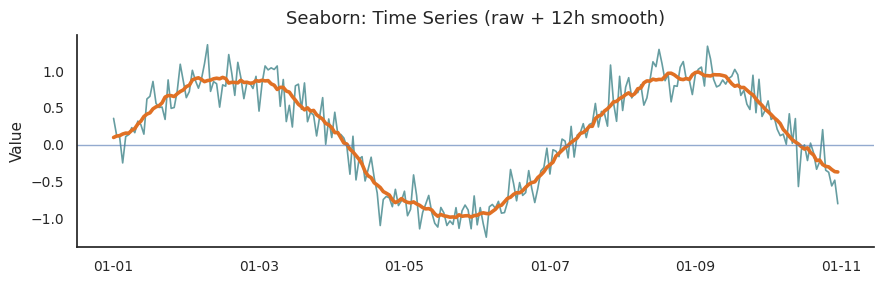

In [7]:
np.random.seed(3)
time = pd.date_range("2025-01-01", periods=240, freq="h")
signal = np.sin(np.linspace(0, 10, 240)) + np.random.randn(240) * 0.2
df_ts = pd.DataFrame({"time": time, "value": signal})

# 趋势线：12 小时滚动均值（展示更好看）
df_ts["smooth"] = df_ts["value"].rolling(window=12, center=True, min_periods=1).mean()

plt.figure(figsize=(9, 3))
ax = plt.gca()

sns.lineplot(data=df_ts, x="time", y="value", lw=1.2, alpha=0.8, ax=ax, color="#40858A")
sns.lineplot(data=df_ts, x="time", y="smooth", lw=2.6, ax=ax, color="#E07024")
ax.axhline(0, lw=1.0, alpha=0.6)
ax.grid(False)
sns.despine(ax=ax)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
ax.set_title("Seaborn: Time Series (raw + 12h smooth)", fontsize=13, pad=8)
ax.set_xlabel("")
ax.set_ylabel("Value", fontsize=11)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig("./gallery/sns_06_timeseries.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **7. Correlation Heatmap**
**图片尺寸:** 6 × 5  
**路径:** `./gallery/sns_07_heatmap.png`

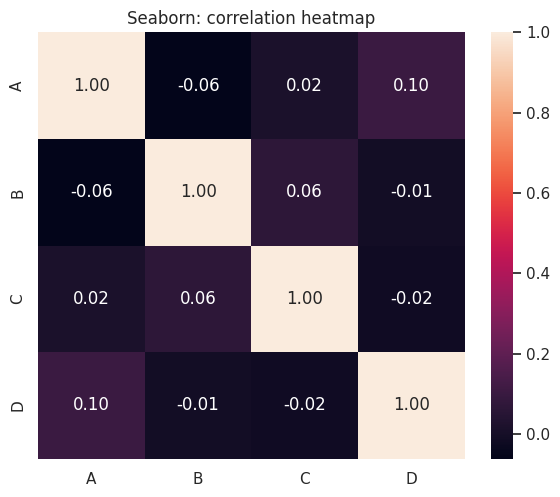

In [8]:
np.random.seed(4)
X = np.random.randn(350, 4)
df_corr = pd.DataFrame(X, columns=["A", "B", "C", "D"])
corr = df_corr.corr()

plt.figure(figsize=(6, 5))
ax = sns.heatmap(corr, annot=True, fmt=".2f", square=True)
ax.grid(False)

plt.title("Seaborn: correlation heatmap")
plt.tight_layout()
plt.savefig("./gallery/sns_07_heatmap.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **8. Pairplot (multi-axes)**
**图片尺寸:** 8 × 8  
**路径:** `./gallery/sns_08_pairplot.png`

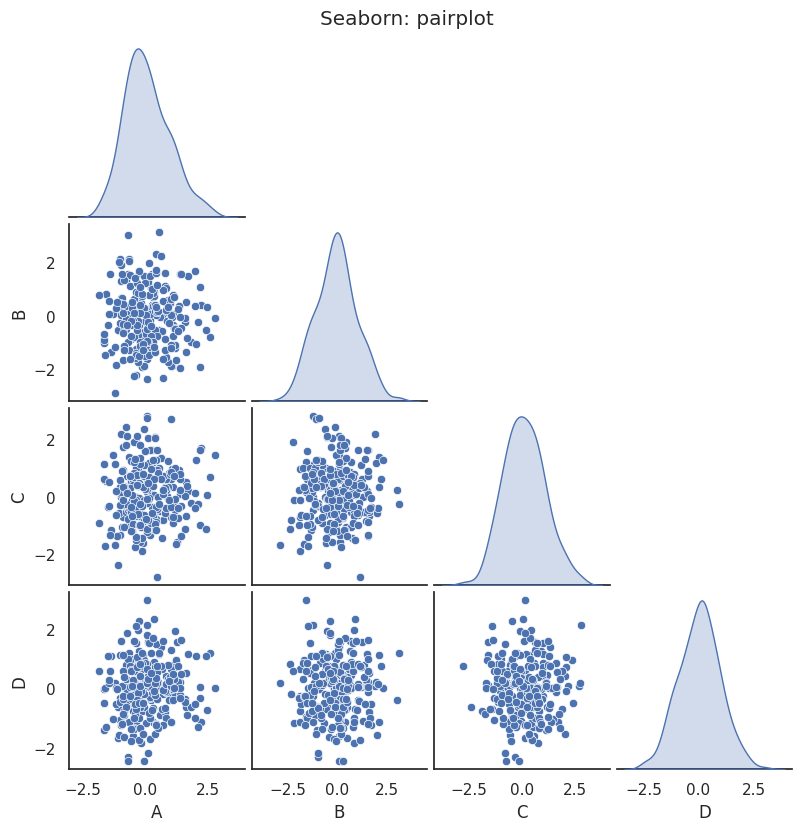

In [9]:
g = sns.pairplot(df_corr.sample(260, random_state=0), corner=True, diag_kind="kde")
g.figure.set_size_inches(8, 8)

# pairplot 需要遍历所有轴关闭网格
for ax in g.axes.flatten():
    if ax is not None:
        ax.grid(False)

g.figure.suptitle("Seaborn: pairplot", y=1.02)
g.figure.savefig("./gallery/sns_08_pairplot.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(g.figure)

### **9. Cartopy: Global field (Robinson) + pcolormesh**
**图片尺寸:** 10 × 5  
**路径:** `./gallery/map_01_global_robinson.png`

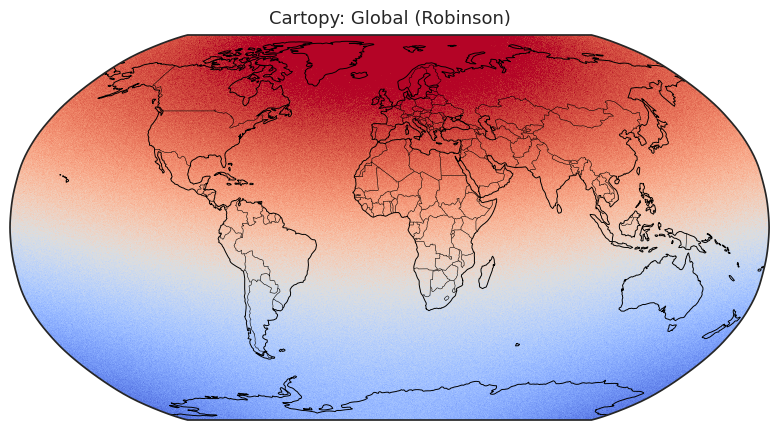

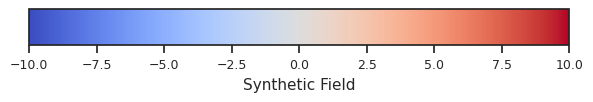

In [10]:
lon = np.linspace(-180, 180, 1441)
lat = np.linspace(-90, 90, 721)
lon2d, lat2d = np.meshgrid(lon, lat)

np.random.seed(10)
field = (
    8.0 * np.sin(np.deg2rad(lat2d))
    + 3.5 * np.cos(np.deg2rad(lon2d / 2.0))
    + np.random.randn(*lat2d.shape) * 0.35
)

# 统一色标范围（非常重要）
vmin = -10
vmax = 10
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = cm.coolwarm

# -------------------------
# Draw map (NO colorbar)
# -------------------------
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_title("Cartopy: Global (Robinson)", fontsize=13, pad=8)

ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.35)
ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

pm = ax.pcolormesh(
    lon2d,
    lat2d,
    field,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmap,
    norm=norm,
    rasterized=True
)

plt.savefig("./gallery/map_01_global_robinson.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

# 与主图完全一致
vmin = -10
vmax = 10
norm = Normalize(vmin=vmin, vmax=vmax)

# -------------------------
# Horizontal colorbar
# -------------------------
fig = plt.figure(figsize=(6, 1.2))
ax = fig.add_axes([0.05, 0.35, 0.9, 0.3])  # [left, bottom, width, height]

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, cax=ax, orientation="horizontal")

cbar.set_label("Synthetic Field", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.savefig("./gallery/map_01_global_colorbar.png", dpi=DPI, bbox_inches="tight", transparent=True)
plt.show()
plt.close()


### **10. Cartopy: Global field (Mollweide) + contourf**
**图片尺寸:** 10 × 5  
**路径:** `./gallery/map_02_global_mollweide.png`

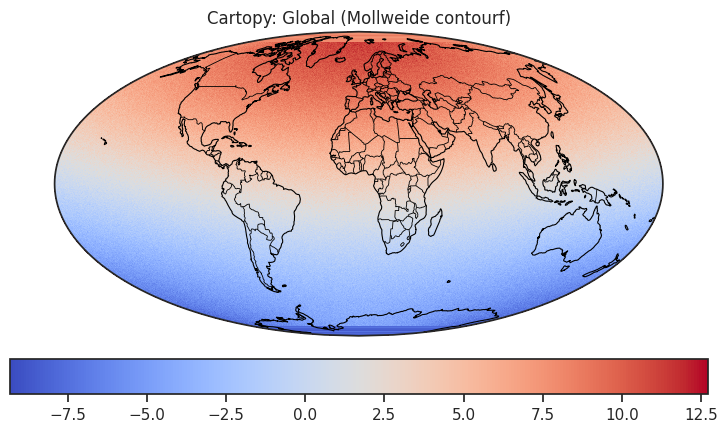

In [11]:
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Mollweide())
ax.set_title("Cartopy: Global (Mollweide contourf)")

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

cm = ax.pcolormesh(lon2d, lat2d, field, 
                   transform=ccrs.PlateCarree(),
                   shading='auto', 
                   cmap=cmap,  # 或者你原来的 cmap
                   rasterized=True)
plt.colorbar(cm, ax=ax, orientation="horizontal", pad=0.06, shrink=0.9)

plt.savefig("./gallery/map_02_global_mollweide.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **11. Cartopy: East Asia (Lambert) + contour**
**图片尺寸:** 9 × 6  
**路径:** `./gallery/map_03_eastasia_lambert_contour.png`

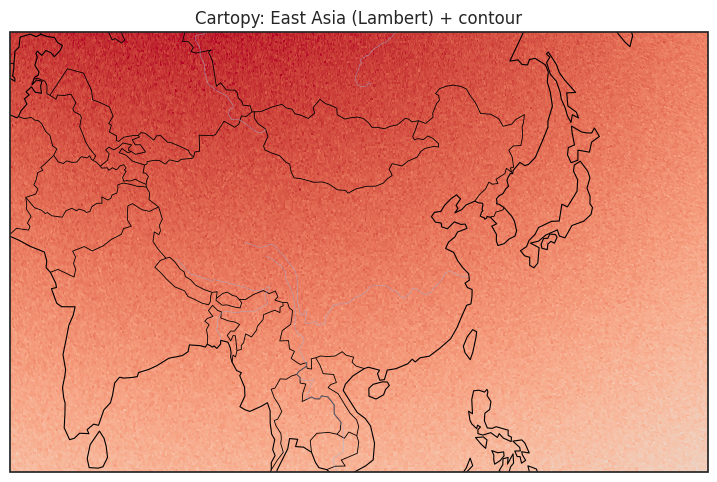

In [13]:
plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=110, central_latitude=35))
ax.set_title("Cartopy: East Asia (Lambert) + contour")

ax.set_extent([70, 145, 10, 55], crs=ccrs.PlateCarree())

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.RIVERS, linewidth=0.4, alpha=0.7)

cs = ax.pcolormesh(lon2d, lat2d, field, transform=ccrs.PlateCarree(), shading="auto", cmap=cmap, norm=norm, rasterized=True)
# ax.clabel(cs, inline=True, fontsize=8)

plt.savefig("./gallery/map_03_eastasia_lambert_contour.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **12. Cartopy: East Asia + pcolormesh + quiver**
**图片尺寸:** 9 × 6  
**路径:** `./gallery/map_04_eastasia_quiver.png`

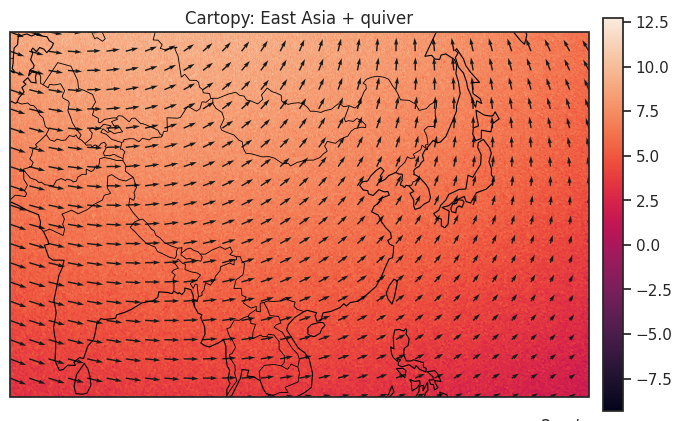

In [14]:
u = 2.0 * np.cos(np.deg2rad(lat2d)) * np.cos(np.deg2rad(lon2d / 2.0))
v = 2.0 * np.sin(np.deg2rad(lat2d)) * np.sin(np.deg2rad(lon2d / 3.0))

plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=110, central_latitude=35))
ax.set_title("Cartopy: East Asia + quiver")

ax.set_extent([70, 145, 10, 55], crs=ccrs.PlateCarree())

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

pm = ax.pcolormesh(lon2d, lat2d, field, transform=ccrs.PlateCarree())
plt.colorbar(pm, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)

skip = (slice(None, None, 5), slice(None, None, 5))
q = ax.quiver(lon2d[skip], lat2d[skip], u[skip], v[skip], transform=ccrs.PlateCarree(), regrid_shape=20)
ax.quiverkey(q, 0.9, -0.08, 2.0, "2 m/s", labelpos="E")

plt.savefig("./gallery/map_04_eastasia_quiver.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **13. Cartopy: Orthographic globe view + contourf**
**图片尺寸:** 7 × 7  
**路径:** `./gallery/map_05_orthographic.png`

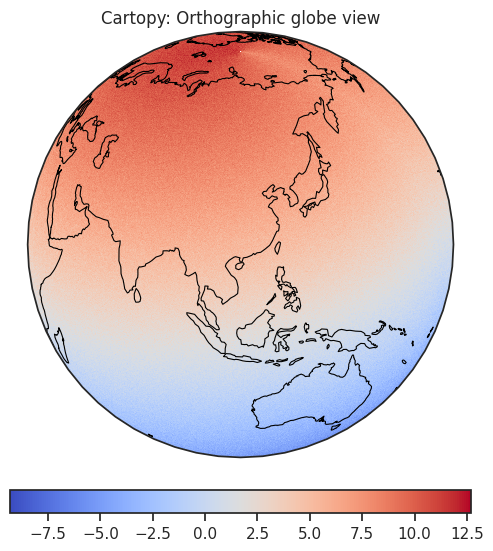

In [17]:
plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=110, central_latitude=25))
ax.set_title("Cartopy: Orthographic globe view")

ax.coastlines(linewidth=0.8)

cf = ax.pcolormesh(lon2d, lat2d, field, transform=ccrs.PlateCarree(), shading='auto', cmap=cmap, rasterized=True)
plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.06, shrink=0.85)

plt.savefig("./gallery/map_05_orthographic.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **14. FacetGrid (small multiples)**
**图片尺寸:** 9 × 6  
**路径:** `./gallery/sns_14_facetgrid.png`

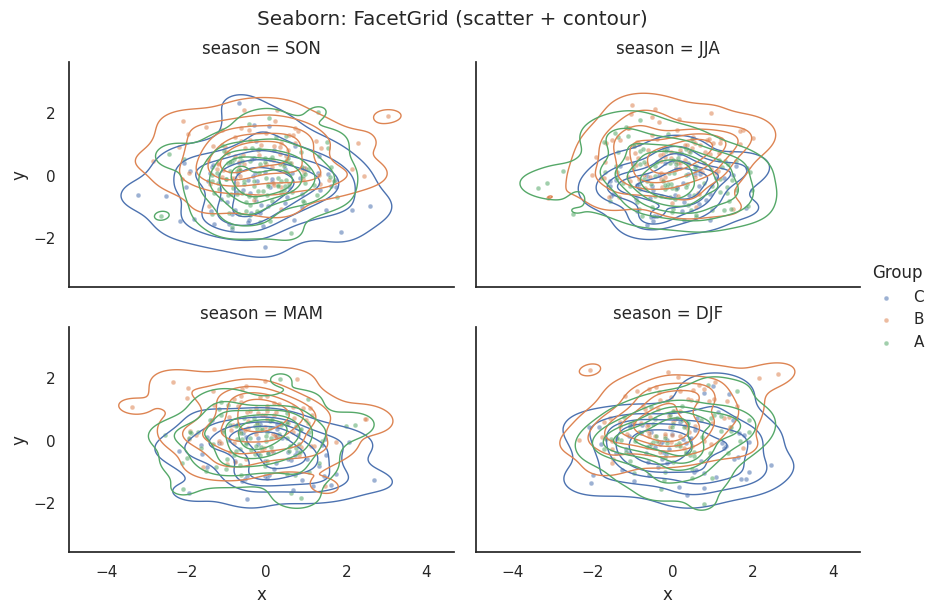

In [19]:
np.random.seed(14)
n = 900
df_fg = pd.DataFrame({
    "x": np.random.randn(n),
    "y": np.random.randn(n) * 0.7 + np.random.randn(n) * 0.2,
    "group": np.random.choice(["A", "B", "C"], size=n, p=[0.4, 0.35, 0.25]),
    "season": np.random.choice(["DJF", "MAM", "JJA", "SON"], size=n)
})
df_fg["y"] = df_fg["y"] + (df_fg["group"] == "B") * 0.6 + (df_fg["group"] == "C") * (-0.4)

g = sns.FacetGrid(df_fg, col="season", hue="group", col_wrap=2, height=3.0, aspect=1.25)
g.map_dataframe(sns.scatterplot, x="x", y="y", s=12, alpha=0.55)
g.map_dataframe(sns.kdeplot, x="x", y="y", levels=6, linewidths=1, fill=False)

g.figure.set_size_inches(9, 6)
g.add_legend(title="Group")

for ax in g.axes.flatten():
    ax.grid(False)
    sns.despine(ax=ax)

g.figure.suptitle("Seaborn: FacetGrid (scatter + contour)", y=1.02)
g.figure.savefig("./gallery/sns_14_facetgrid.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(g.figure)

### **15. Catplot (bar + error)**
**图片尺寸:** 8 × 5  
**路径:** `./gallery/sns_15_catplot_bar.png`

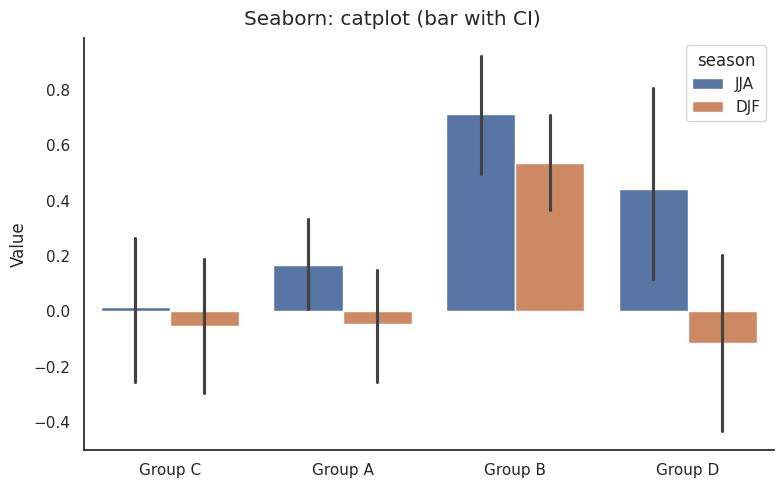

In [20]:
np.random.seed(15)
n = 600
df_cat = pd.DataFrame({
    "cat": np.random.choice(["Group A", "Group B", "Group C", "Group D"], size=n, p=[0.35, 0.3, 0.2, 0.15]),
    "season": np.random.choice(["DJF", "JJA"], size=n),
    "value": np.random.randn(n)
})
df_cat["value"] += (df_cat["cat"] == "Group B") * 0.6 + (df_cat["cat"] == "Group C") * (-0.3) + (df_cat["season"] == "JJA") * 0.2

g = sns.catplot(
    data=df_cat, x="cat", y="value", hue="season",
    kind="bar", height=5, aspect=1.6, errorbar=("ci", 95),
    legend_out=False
)

g.figure.set_size_inches(8, 5)
g.ax.grid(False)
sns.despine(ax=g.ax)

g.ax.set_xlabel("")
g.ax.set_ylabel("Value")
g.figure.suptitle("Seaborn: catplot (bar with CI)", y=1.02)

g.figure.savefig("./gallery/sns_15_catplot_bar.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(g.figure)

### **16. Clustermap (heatmap + dendrogram)**
**图片尺寸:** 9 × 7  
**路径:** `./gallery/sns_16_clustermap.png`

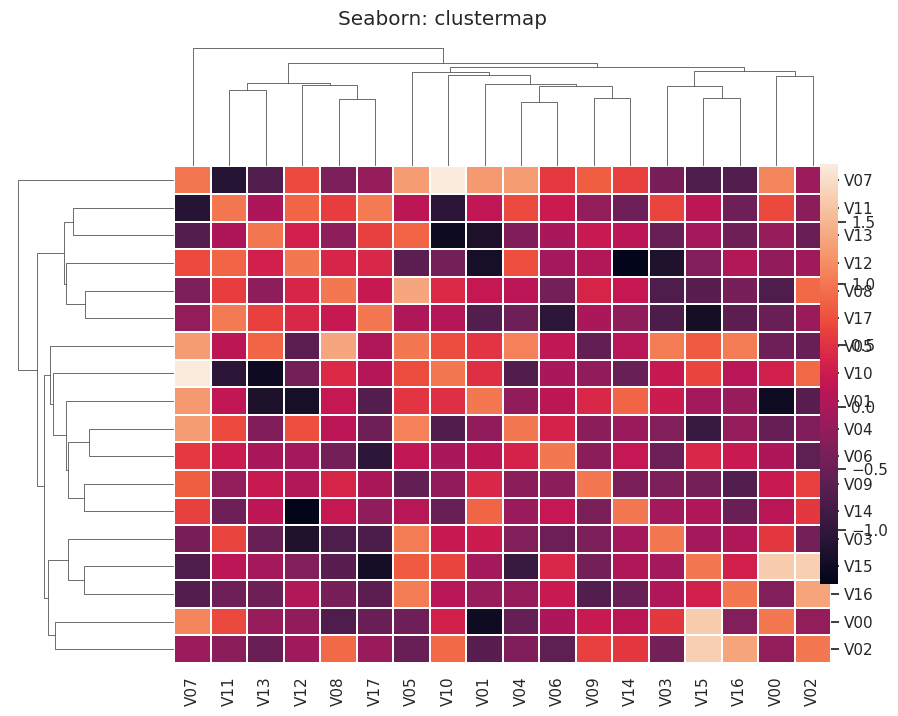

In [21]:
np.random.seed(16)
m = 18
X = np.random.randn(m, m)
X = (X + X.T) / 2.0  # symmetric
np.fill_diagonal(X, 1.0)
df_cm = pd.DataFrame(X, columns=[f"V{i:02d}" for i in range(m)], index=[f"V{i:02d}" for i in range(m)])

g = sns.clustermap(
    df_cm,
    figsize=(9, 7),
    annot=False,
    linewidths=0.3,
    cbar_pos=(0.92, 0.2, 0.02, 0.6)  # 右侧独立色标位置
)

# clustermap 不用 grid；统一去边框
for ax in g.fig.axes:
    ax.grid(False)

g.fig.suptitle("Seaborn: clustermap", y=1.02)
g.fig.savefig("./gallery/sns_16_clustermap.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(g.fig)

### **17. Hexbin (dense scatter alternative)**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_17_hexbin.png`

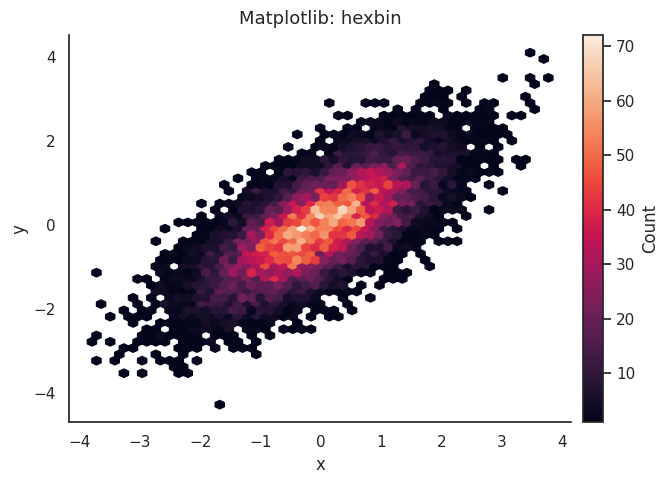

In [22]:
np.random.seed(17)
n = 12000
x = np.random.randn(n)
y = 0.7 * x + np.random.randn(n) * 0.7

plt.figure(figsize=(7, 5))
ax = plt.gca()

hb = ax.hexbin(x, y, gridsize=50, mincnt=1)
ax.grid(False)
sns.despine(ax=ax)

cbar = plt.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Count")

ax.set_title("Matplotlib: hexbin", fontsize=13, pad=8)
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.savefig("./gallery/sns_17_hexbin.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **18. ECDF (empirical CDF)**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_18_ecdf.png`

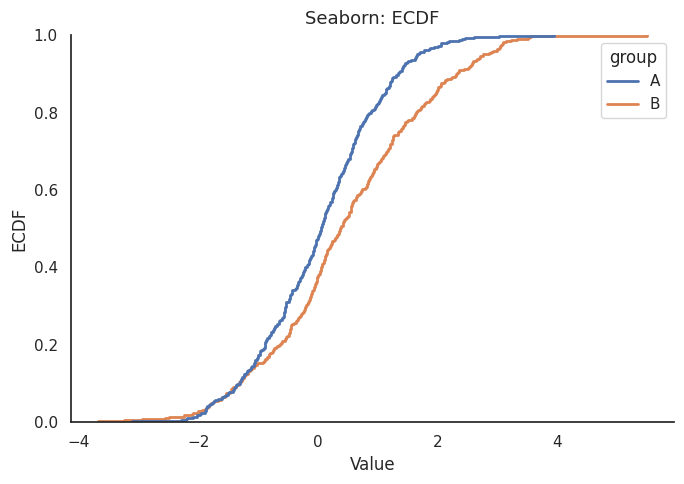

In [23]:
np.random.seed(18)
n = 800
df_ecdf = pd.DataFrame({
    "value": np.r_[np.random.randn(n//2), np.random.randn(n//2) * 1.3 + 0.5],
    "group": ["A"] * (n//2) + ["B"] * (n//2)
})

plt.figure(figsize=(7, 5))
ax = sns.ecdfplot(data=df_ecdf, x="value", hue="group", linewidth=2)

ax.grid(False)
sns.despine(ax=ax)

ax.set_title("Seaborn: ECDF", fontsize=13, pad=8)
ax.set_xlabel("Value")
ax.set_ylabel("ECDF")

plt.tight_layout()
plt.savefig("./gallery/sns_18_ecdf.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **19. Cartopy: GeoAxes gridline labels (with formatted ticks)**
**图片尺寸:** 9 × 6  
**路径:** `./gallery/map_19_gridline_labels.png`

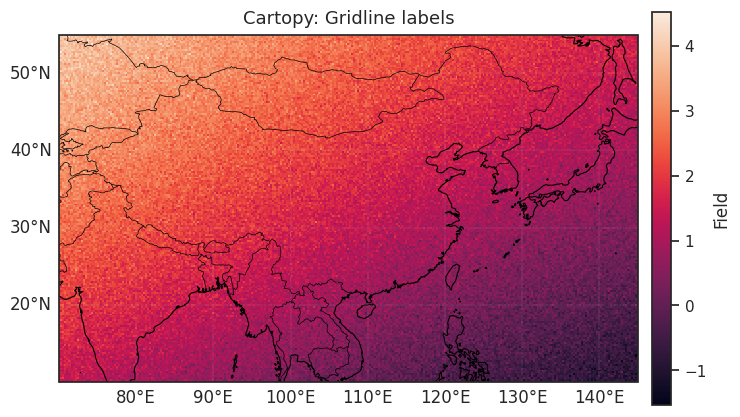

In [24]:
lon = np.linspace(70, 145, 301)
lat = np.linspace(10, 55, 181)
lon2d, lat2d = np.meshgrid(lon, lat)

np.random.seed(19)
field = np.sin(np.deg2rad(lat2d)) * 4 + np.cos(np.deg2rad(lon2d)) * 2 + np.random.randn(*lat2d.shape) * 0.25

plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([70, 145, 10, 55], crs=ccrs.PlateCarree())
ax.set_title("Cartopy: Gridline labels", fontsize=13, pad=8)

ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.35)
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

pm = ax.pcolormesh(lon2d, lat2d, field, shading="auto", transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.6, linestyle="--")
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(pm, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
cbar.set_label("Field")

plt.savefig("./gallery/map_19_gridline_labels.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **20. Inset subplot (main + zoom-in)**
**图片尺寸:** 9 × 6  
**路径:** `./gallery/map_20_inset_zoom.png`

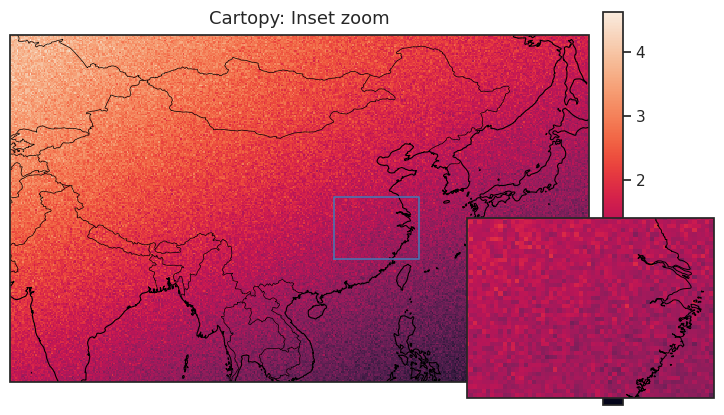

In [25]:
lon = np.linspace(70, 145, 401)
lat = np.linspace(10, 55, 241)
lon2d, lat2d = np.meshgrid(lon, lat)

np.random.seed(20)
field = np.sin(np.deg2rad(lat2d)) * 4 + np.cos(np.deg2rad(lon2d)) * 2 + np.random.randn(*lat2d.shape) * 0.25

plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([70, 145, 10, 55], crs=ccrs.PlateCarree())
ax.set_title("Cartopy: Inset zoom", fontsize=13, pad=8)

ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.35)
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

pm = ax.pcolormesh(lon2d, lat2d, field, shading="auto", transform=ccrs.PlateCarree())
plt.colorbar(pm, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)

# Inset axes（缩放小窗）
inset = plt.axes([0.62, 0.18, 0.30, 0.30], projection=ccrs.PlateCarree())
inset.set_extent([112, 123, 26, 34], crs=ccrs.PlateCarree())  # 华东区域示例
inset.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.35)
inset.coastlines(linewidth=0.7)

inset.pcolormesh(lon2d, lat2d, field, shading="auto", transform=ccrs.PlateCarree())

# 主图标出 inset 范围
ax.plot([112, 123, 123, 112, 112], [26, 26, 34, 34, 26], transform=ccrs.PlateCarree(), linewidth=1.2)

plt.savefig("./gallery/map_20_inset_zoom.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **21. Dual colorbars (two fields)**
**图片尺寸:** 9 × 6  
**路径:** `./gallery/map_21_dual_colorbar.png`

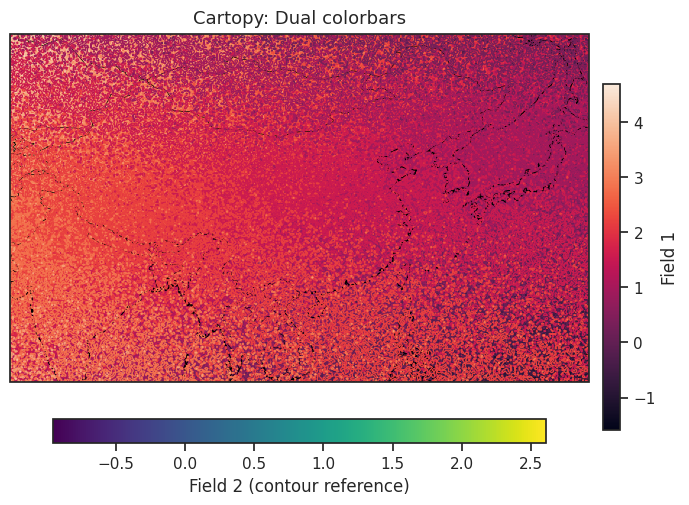

In [26]:
lon = np.linspace(70, 145, 401)
lat = np.linspace(10, 55, 241)
lon2d, lat2d = np.meshgrid(lon, lat)

np.random.seed(21)
field1 = np.sin(np.deg2rad(lat2d)) * 4 + np.cos(np.deg2rad(lon2d)) * 2 + np.random.randn(*lat2d.shape) * 0.25
field2 = np.cos(np.deg2rad(lat2d)) * 3 - np.sin(np.deg2rad(lon2d/2)) * 2 + np.random.randn(*lat2d.shape) * 0.25

plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([70, 145, 10, 55], crs=ccrs.PlateCarree())
ax.set_title("Cartopy: Dual colorbars", fontsize=13, pad=8)

ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.25)
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

pm1 = ax.pcolormesh(lon2d, lat2d, field1, shading="auto", transform=ccrs.PlateCarree())
cs2 = ax.contour(lon2d, lat2d, field2, levels=10, transform=ccrs.PlateCarree(), linewidths=0.9)

# colorbar 1：底图
cbar1 = plt.colorbar(pm1, ax=ax, orientation="vertical", pad=0.02, shrink=0.75)
cbar1.set_label("Field 1")

# colorbar 2：等值线，单独生成一个 mappable
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

norm2 = Normalize(vmin=np.nanmin(field2), vmax=np.nanmax(field2))
sm2 = ScalarMappable(norm=norm2, cmap=cm.viridis)
sm2.set_array([])

# 放到下方横向色标
cbar2 = plt.colorbar(sm2, ax=ax, orientation="horizontal", pad=0.08, shrink=0.85)
cbar2.set_label("Field 2 (contour reference)")

plt.savefig("./gallery/map_21_dual_colorbar.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **22. Transparent background PNG (overlay-ready)**
**图片尺寸:** 7 × 5  
**路径:** `./gallery/sns_22_transparent_overlay.png`

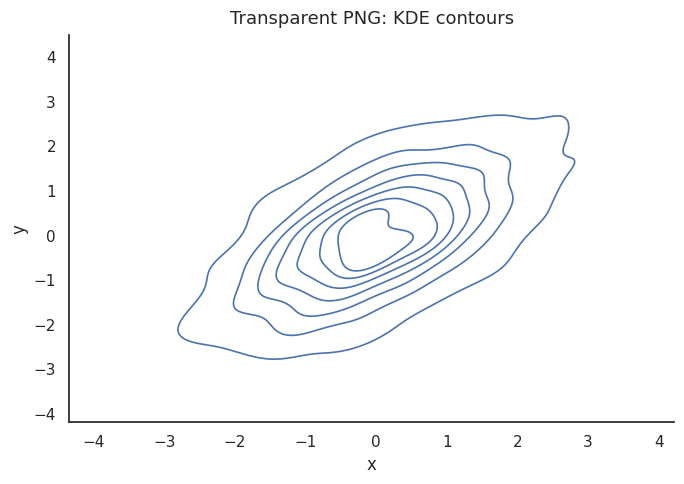

In [27]:
np.random.seed(22)
x = np.random.randn(1200)
y = 0.6 * x + np.random.randn(1200) * 0.9

plt.figure(figsize=(7, 5))
ax = plt.gca()

# 只用密度轮廓，透明背景更适合叠加
sns.kdeplot(x=x, y=y, levels=8, linewidths=1.2, fill=False, ax=ax)

ax.grid(False)
sns.despine(ax=ax)

ax.set_title("Transparent PNG: KDE contours", fontsize=13, pad=8)
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.savefig("./gallery/sns_22_transparent_overlay.png", dpi=DPI, bbox_inches="tight", transparent=True)
plt.show()
plt.close()

### **23. Ultra-wide Time Series + Long Legend**
**图片尺寸:** 16 × 3  
**路径:** `./gallery/sns_23_ultrawide_timeseries_longlegend.png`

/tmp/ipykernel_1716180/2646152668.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  t = pd.date_range("2025-01-01", periods=480, freq="H")


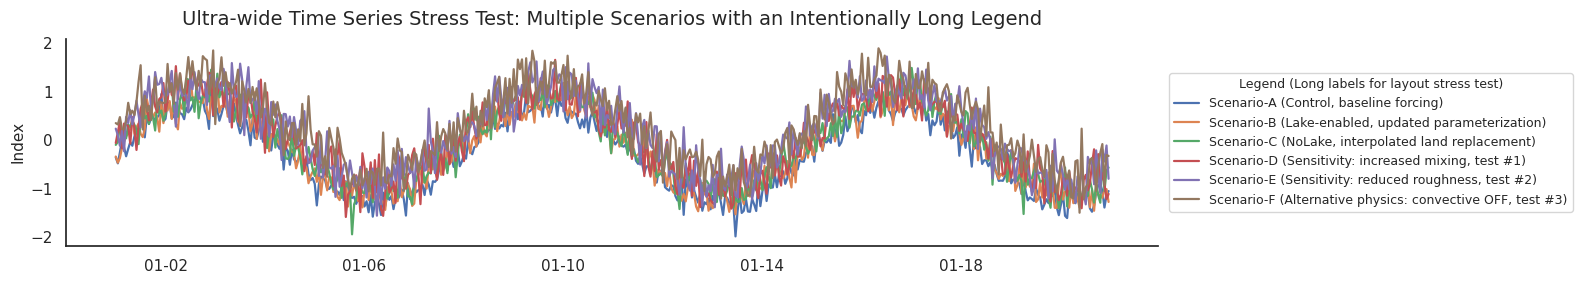

In [28]:
np.random.seed(2301)

t = pd.date_range("2025-01-01", periods=480, freq="H")
base = np.sin(np.linspace(0, 18, len(t)))

series_names = [
    "Scenario-A (Control, baseline forcing)",
    "Scenario-B (Lake-enabled, updated parameterization)",
    "Scenario-C (NoLake, interpolated land replacement)",
    "Scenario-D (Sensitivity: increased mixing, test #1)",
    "Scenario-E (Sensitivity: reduced roughness, test #2)",
    "Scenario-F (Alternative physics: convective OFF, test #3)",
]

data = []
for i, name in enumerate(series_names):
    noise = np.random.randn(len(t)) * (0.18 + 0.03 * i)
    shift = (i - 2.5) * 0.12
    data.append(pd.DataFrame({"time": t, "value": base + noise + shift, "label": name}))

df_wide = pd.concat(data, ignore_index=True)

plt.figure(figsize=(16, 3))
ax = plt.gca()

sns.lineplot(data=df_wide, x="time", y="value", hue="label", lw=1.6, ax=ax)

ax.grid(False)
sns.despine(ax=ax)

# 时间轴更简洁（超宽图也要控刻度密度）
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_xlabel("")
ax.set_ylabel("Index", fontsize=11)

plt.title(
    "Ultra-wide Time Series Stress Test: Multiple Scenarios with an Intentionally Long Legend",
    fontsize=14, pad=10
)

# 图例放到图外，刻意很长，用于压测排版
leg = ax.legend(
    title="Legend (Long labels for layout stress test)",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
    borderaxespad=0.0,
    fontsize=9,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig("./gallery/sns_23_ultrawide_timeseries_longlegend.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **24. Ultra-tall Distribution Panel + Long Legend**
**图片尺寸:** 3.2 × 14  
**路径:** `./gallery/sns_24_ultratall_kde_longlegend.png`

/tmp/ipykernel_1716180/1383154743.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(


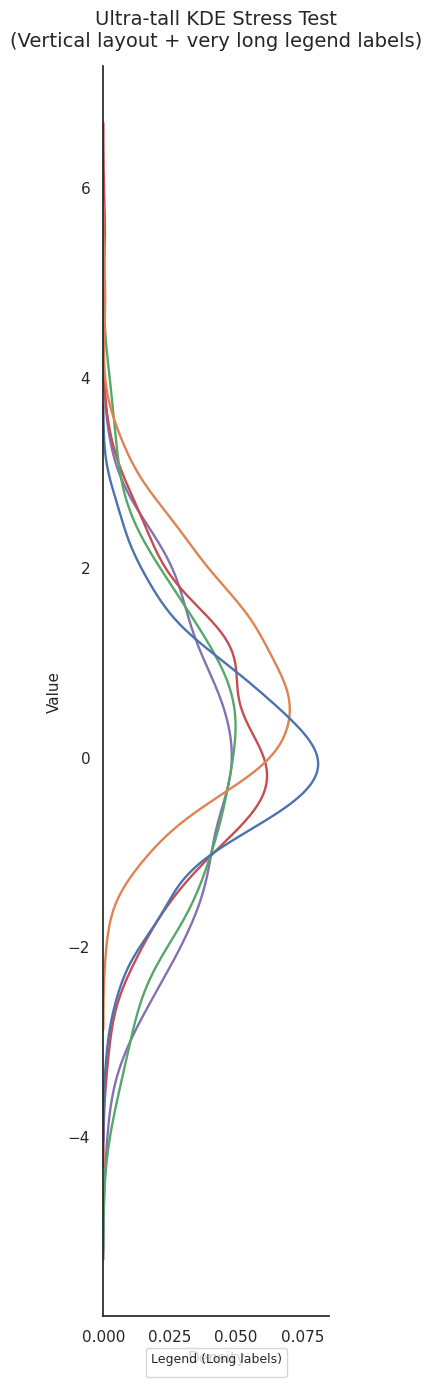

In [29]:
np.random.seed(2401)

n = 1800
groups = [
    "Group A — Reference distribution (baseline)",
    "Group B — Shifted mean (warming-like perturbation)",
    "Group C — Wider spread (enhanced variability)",
    "Group D — Skewed tail (extreme-event sensitivity)",
    "Group E — Bimodal mixture (regime switching)",
]

vals = []
labels = []
for i, name in enumerate(groups):
    if i == 0:
        v = np.random.randn(n//5)
    elif i == 1:
        v = np.random.randn(n//5) + 0.8
    elif i == 2:
        v = np.random.randn(n//5) * 1.5
    elif i == 3:
        v = np.random.randn(n//5) * 1.1 + np.random.exponential(0.8, n//5) * 0.6 - 0.2
    else:
        v = np.r_[np.random.randn(n//10) - 1.2, np.random.randn(n//10) + 1.0]
    vals.append(v)
    labels.append(np.repeat(name, len(v)))

df_tall = pd.DataFrame({"value": np.concatenate(vals), "label": np.concatenate(labels)})

plt.figure(figsize=(3.2, 14))
ax = plt.gca()

# 竖向 KDE：对超高图很友好
sns.kdeplot(data=df_tall, y="value", hue="label", lw=1.7, ax=ax)

ax.grid(False)
sns.despine(ax=ax)

ax.set_xlabel("Density", fontsize=11)
ax.set_ylabel("Value", fontsize=11)

plt.title(
    "Ultra-tall KDE Stress Test\n(Vertical layout + very long legend labels)",
    fontsize=14, pad=14
)

# 长图例放到底部（超高图常用），刻意占空间压测
leg = ax.legend(
    title="Legend (Long labels)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=1,
    frameon=True,
    fontsize=9,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig("./gallery/sns_24_ultratall_kde_longlegend.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **25. Panoramic Categorical Bars + Very Long Legend**
**图片尺寸:** 18 × 4  
**路径:** `./gallery/sns_25_panoramic_bars_longlegend.png`

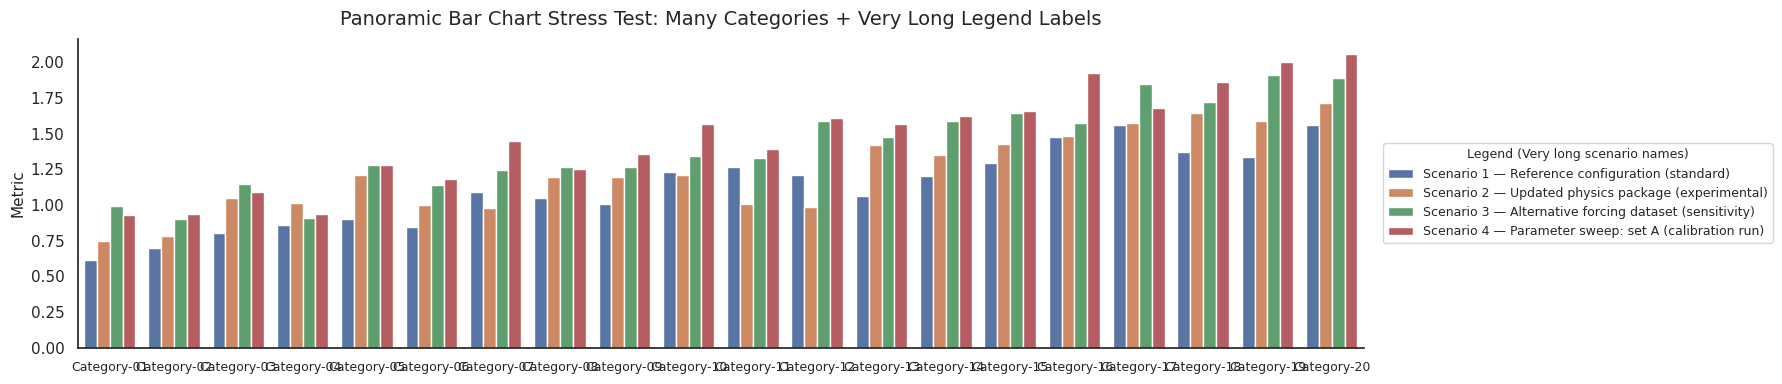

In [30]:
np.random.seed(2501)

cats = [f"Category-{i:02d}" for i in range(1, 21)]
scenarios = [
    "Scenario 1 — Reference configuration (standard)",
    "Scenario 2 — Updated physics package (experimental)",
    "Scenario 3 — Alternative forcing dataset (sensitivity)",
    "Scenario 4 — Parameter sweep: set A (calibration run)",
]

rows = []
for s_i, s in enumerate(scenarios):
    base = np.linspace(0.8, 1.8, len(cats)) + np.random.randn(len(cats)) * 0.12
    offset = (s_i - 1.5) * 0.12
    vals = base + offset
    for c, v in zip(cats, vals):
        rows.append({"category": c, "value": v, "scenario": s})

df_bar = pd.DataFrame(rows)

plt.figure(figsize=(18, 4))
ax = plt.gca()

sns.barplot(data=df_bar, x="category", y="value", hue="scenario", ax=ax)

ax.grid(False)
sns.despine(ax=ax)

ax.set_title(
    "Panoramic Bar Chart Stress Test: Many Categories + Very Long Legend Labels",
    fontsize=14, pad=10
)
ax.set_xlabel("")
ax.set_ylabel("Metric", fontsize=11)

# x 轴标签旋转（横向超宽图典型）
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)

# 超长图例放到右侧图外
leg = ax.legend(
    title="Legend (Very long scenario names)",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig("./gallery/sns_25_panoramic_bars_longlegend.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **26. Ultra-wide Multi-line + Bottom Legend (ncol=4)**
**图片尺寸:** 18 × 3.6  
**路径:** `./gallery/sns_26_ultrawide_multiline_bottomlegend_ncol4.png`

/tmp/ipykernel_1716180/1639615151.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  t = pd.date_range("2025-01-01", periods=360, freq="H")


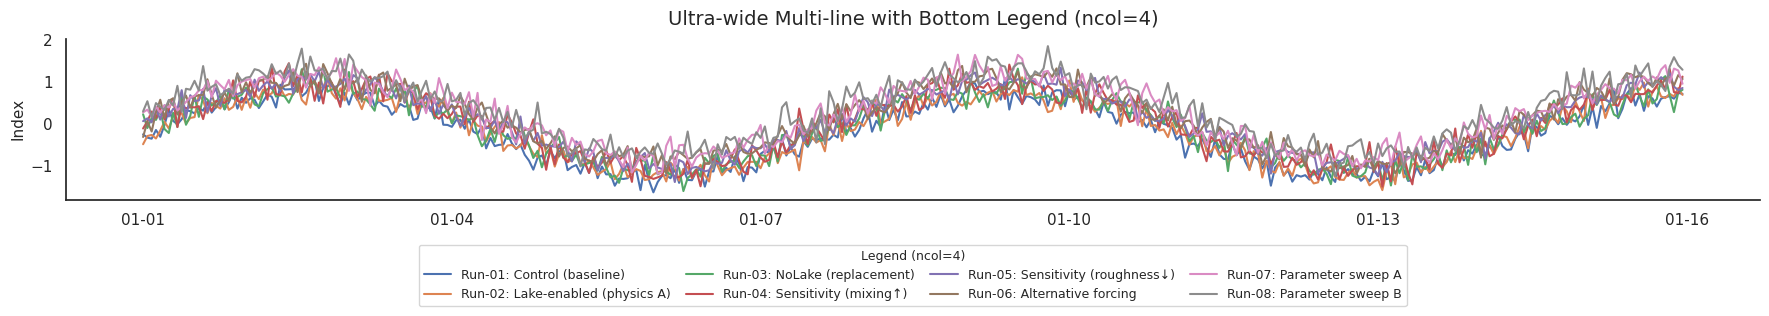

In [31]:
np.random.seed(2601)

t = pd.date_range("2025-01-01", periods=360, freq="H")
base = np.sin(np.linspace(0, 14, len(t)))

labels = [
    "Run-01: Control (baseline)",
    "Run-02: Lake-enabled (physics A)",
    "Run-03: NoLake (replacement)",
    "Run-04: Sensitivity (mixing↑)",
    "Run-05: Sensitivity (roughness↓)",
    "Run-06: Alternative forcing",
    "Run-07: Parameter sweep A",
    "Run-08: Parameter sweep B",
]

rows = []
for i, lab in enumerate(labels):
    noise = np.random.randn(len(t)) * (0.16 + 0.02 * (i % 4))
    shift = (i - 3.5) * 0.08
    rows.append(pd.DataFrame({"time": t, "value": base + noise + shift, "label": lab}))
df_26 = pd.concat(rows, ignore_index=True)

plt.figure(figsize=(18, 3.6))
ax = plt.gca()

sns.lineplot(data=df_26, x="time", y="value", hue="label", lw=1.5, ax=ax)

ax.grid(False)
sns.despine(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_xlabel("")
ax.set_ylabel("Index", fontsize=11)

plt.title("Ultra-wide Multi-line with Bottom Legend (ncol=4)", fontsize=14, pad=10)

leg = ax.legend(
    title="Legend (ncol=4)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=4,
    frameon=True,
    fontsize=9,
    title_fontsize=9,
    columnspacing=1.2,
    handlelength=2.2
)

plt.tight_layout()
plt.savefig("./gallery/sns_26_ultrawide_multiline_bottomlegend_ncol4.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **27. Ultra-wide Scatter + Bottom Legend (ncol=3)**
**图片尺寸:** 18 × 3.8  
**路径:** `./gallery/sns_27_ultrawide_scatter_bottomlegend_ncol3.png`

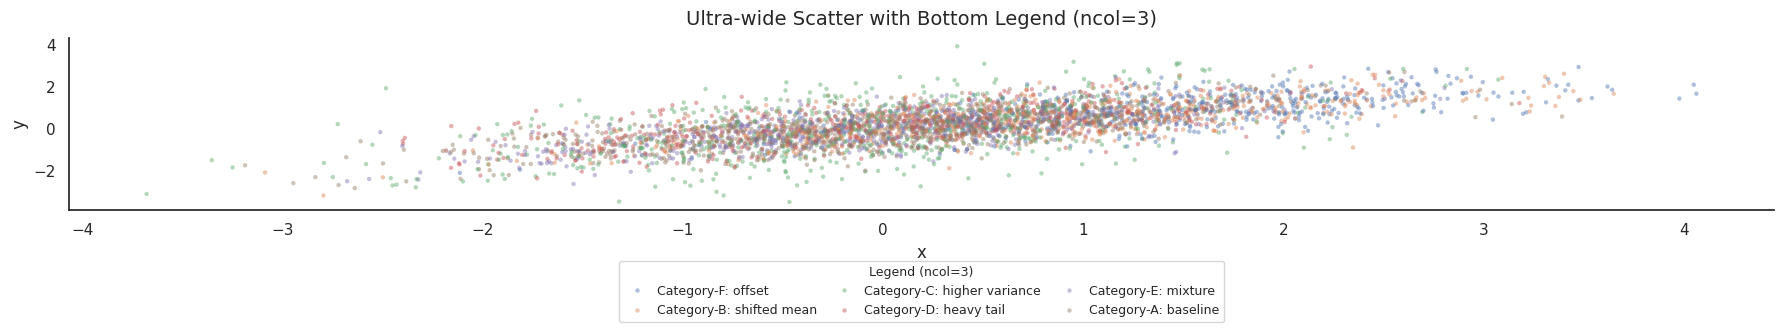

In [32]:
np.random.seed(2701)

n = 4000
groups = [
    "Category-A: baseline",
    "Category-B: shifted mean",
    "Category-C: higher variance",
    "Category-D: heavy tail",
    "Category-E: mixture",
    "Category-F: offset",
]

cat = np.random.choice(groups, size=n, p=[0.22, 0.18, 0.18, 0.14, 0.14, 0.14])
x = np.random.randn(n) + (cat == groups[1]) * 0.7 + (cat == groups[5]) * 1.2
y = 0.6 * x + np.random.randn(n) * (0.6 + (cat == groups[2]) * 0.5) + (cat == groups[3]) * (np.random.exponential(0.4, n) * 0.4)

df_27 = pd.DataFrame({"x": x, "y": y, "cat": cat})

plt.figure(figsize=(18, 3.8))
ax = plt.gca()

sns.scatterplot(data=df_27, x="x", y="y", hue="cat", s=10, alpha=0.45, ax=ax, linewidth=0)

ax.grid(False)
sns.despine(ax=ax)

ax.set_title("Ultra-wide Scatter with Bottom Legend (ncol=3)", fontsize=14, pad=10)
ax.set_xlabel("x")
ax.set_ylabel("y")

leg = ax.legend(
    title="Legend (ncol=3)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.26),
    ncol=3,
    frameon=True,
    fontsize=9,
    title_fontsize=9,
    columnspacing=1.2,
    handletextpad=0.6
)

plt.tight_layout()
plt.savefig("./gallery/sns_27_ultrawide_scatter_bottomlegend_ncol3.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **28. Ultra-wide Stacked-like Area (fill_between) + Bottom Legend (ncol=4)**
**图片尺寸:** 18 × 3.8  
**路径:** `./gallery/sns_28_ultrawide_area_bottomlegend_ncol4.png`

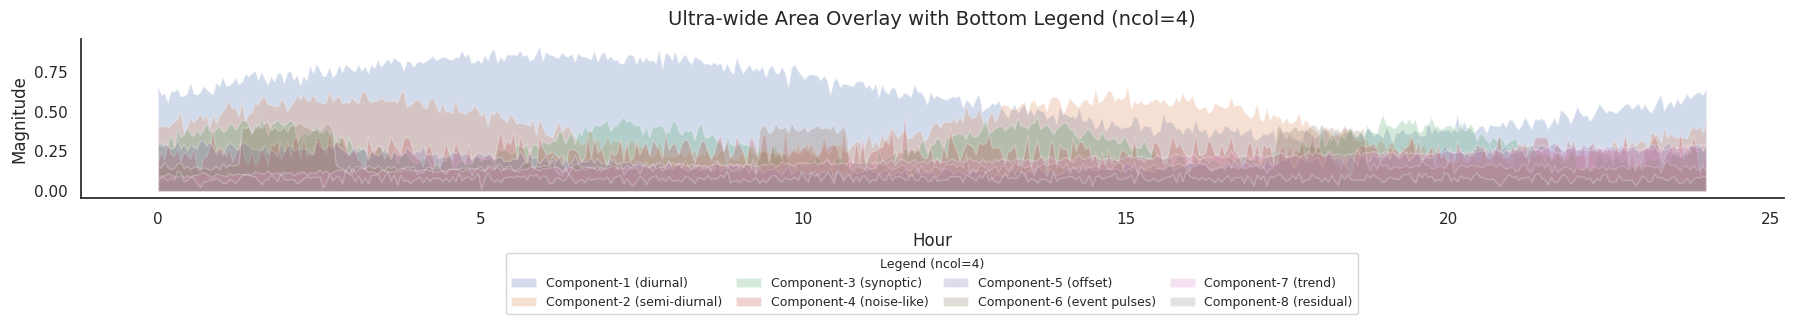

In [33]:
np.random.seed(2801)

t = np.linspace(0, 24, 480)
series = []
names = [
    "Component-1 (diurnal)",
    "Component-2 (semi-diurnal)",
    "Component-3 (synoptic)",
    "Component-4 (noise-like)",
    "Component-5 (offset)",
    "Component-6 (event pulses)",
    "Component-7 (trend)",
    "Component-8 (residual)",
]

for i, name in enumerate(names):
    if i == 0:
        y = 0.6 + 0.25 * np.sin(2*np.pi*t/24) + np.random.randn(len(t)) * 0.03
    elif i == 1:
        y = 0.4 + 0.18 * np.sin(2*np.pi*t/12) + np.random.randn(len(t)) * 0.03
    elif i == 2:
        y = 0.3 + 0.12 * np.sin(2*np.pi*t/6) + np.random.randn(len(t)) * 0.03
    elif i == 3:
        y = 0.25 + np.random.randn(len(t)) * 0.06
    elif i == 4:
        y = 0.2 + 0.08 * np.cos(2*np.pi*t/24) + np.random.randn(len(t)) * 0.02
    elif i == 5:
        pulses = (np.sin(2*np.pi*t/8) > 0.85).astype(float) * 0.25
        y = 0.15 + pulses + np.random.randn(len(t)) * 0.02
    elif i == 6:
        y = 0.1 + (t/24) * 0.18 + np.random.randn(len(t)) * 0.01
    else:
        y = 0.08 + np.random.randn(len(t)) * 0.02

    series.append((name, np.clip(y, 0, None)))

plt.figure(figsize=(18, 3.8))
ax = plt.gca()

# 多条 area 叠加（不是严格 stacked，但很适合压测视觉与图例）
for name, y in series:
    ax.fill_between(t, y, alpha=0.25, label=name)

ax.grid(False)
sns.despine(ax=ax)

ax.set_title("Ultra-wide Area Overlay with Bottom Legend (ncol=4)", fontsize=14, pad=10)
ax.set_xlabel("Hour")
ax.set_ylabel("Magnitude")

leg = ax.legend(
    title="Legend (ncol=4)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=4,
    frameon=True,
    fontsize=9,
    title_fontsize=9,
    columnspacing=1.1,
    handlelength=2.0
)

plt.tight_layout()
plt.savefig("./gallery/sns_28_ultrawide_area_bottomlegend_ncol4.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

### **29. Ultra-wide Multi-category Lines + Bottom Legend (ncol=4)**
**图片尺寸:** 18 × 3.6  
**路径:** `./gallery/sns_29_ultrawide_lines_bottomlegend_ncol4.png`

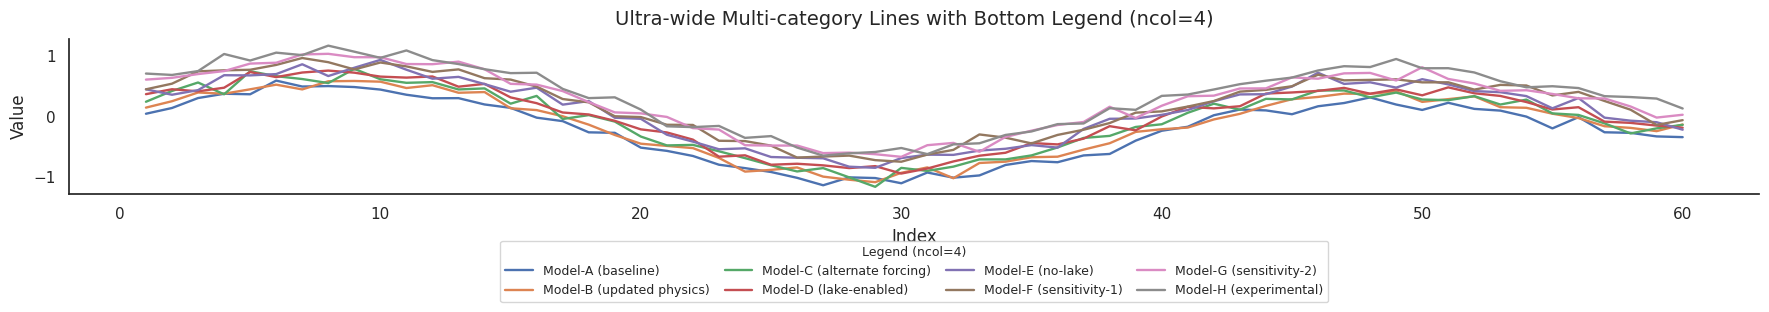

In [34]:
np.random.seed(2901)

x = np.arange(1, 61)

labels = [
    "Model-A (baseline)",
    "Model-B (updated physics)",
    "Model-C (alternate forcing)",
    "Model-D (lake-enabled)",
    "Model-E (no-lake)",
    "Model-F (sensitivity-1)",
    "Model-G (sensitivity-2)",
    "Model-H (experimental)",
]

rows = []
for i, lab in enumerate(labels):
    y = 0.6*np.sin(x/6) + 0.25*np.cos(x/11) + np.random.randn(len(x)) * (0.06 + 0.01*(i%3)) + (i-3.5)*0.08
    rows.append(pd.DataFrame({"x": x, "y": y, "label": lab}))
df_29 = pd.concat(rows, ignore_index=True)

plt.figure(figsize=(18, 3.6))
ax = plt.gca()

sns.lineplot(data=df_29, x="x", y="y", hue="label", lw=1.7, ax=ax)

ax.grid(False)
sns.despine(ax=ax)

ax.set_title("Ultra-wide Multi-category Lines with Bottom Legend (ncol=4)", fontsize=14, pad=10)
ax.set_xlabel("Index")
ax.set_ylabel("Value")

leg = ax.legend(
    title="Legend (ncol=4)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.26),
    ncol=4,
    frameon=True,
    fontsize=9,
    title_fontsize=9,
    columnspacing=1.2,
    handlelength=2.2
)

plt.tight_layout()
plt.savefig("./gallery/sns_29_ultrawide_lines_bottomlegend_ncol4.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()